In [1]:
%pip install pandas


Note: you may need to restart the kernel to use updated packages.


Practical simple linear regrression

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('height-weight.csv',sep=",")

In [6]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 0, 'Weight')

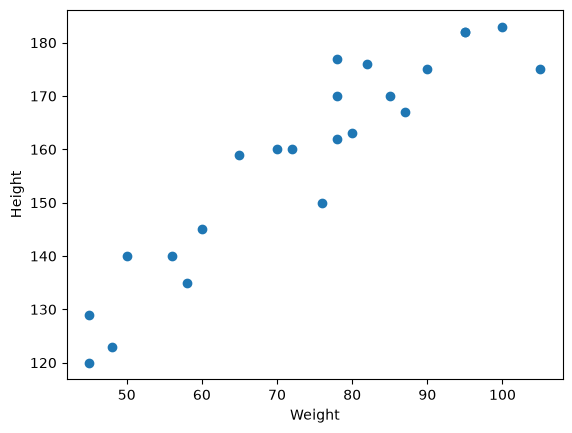

In [7]:
## scatter plot
plt.scatter(df['Weight'], df['Height'])
plt.ylabel('Height')
plt.xlabel('Weight')

In [8]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


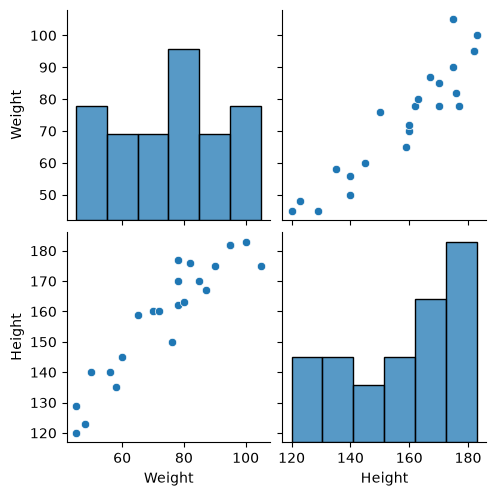

In [9]:
## seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [10]:
## independent and Dependent features 
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [11]:
x=df[['Weight']] ## independent feature should be dataframe or 2D array
y = df['Height'] ## this variable can be 1D or series


In [12]:
x_series=df[['Weight']] ## independent feature should be dataframe or 2D array


In [20]:
from sklearn.preprocessing import StandardScaler

In [13]:
## train test split
from sklearn.model_selection import train_test_split


In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(x,y, test_size=0.25, random_state=42)

In [17]:
X_train

,Weight
1,58
13,100
5,78
2,48
11,95
20,45
3,60
4,70
18,76
16,50


In [19]:
X_test

,Weight
15,78
9,78
0,45
8,95
17,65
12,105


In [ ]:
## standardization if dependent and independent feature have different units then 
# then after standaridization all data point will be converted to U(mean) =0 and standard deviation = 1 

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
# X_train
# scaler.fit()

In [23]:
X_test=scaler.transform(X_test)

In [24]:
## apply simple linear regression
from sklearn.linear_model import LinearRegression

In [25]:
regression=LinearRegression(n_jobs=-1)

In [26]:
regression.fit(X_train,Y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[17.3]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,156.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.12]


In [27]:
regression.intercept_

np.float64(156.47058823529412)

In [28]:
print(f"slope  {regression.coef_}")
print(f"intercept  {regression.intercept_}")

slope  [17.2982057]
intercept  156.47058823529412


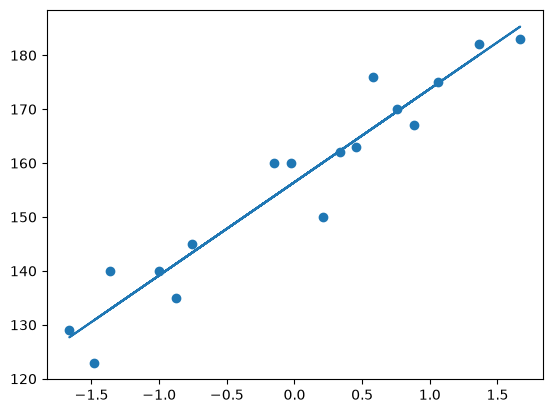

In [29]:
# plot the training data plot best fit line 
plt.scatter(X_train, Y_train)
plt.plot(X_train, regression.predict(X_train))

In [30]:
## Prediction of test data
# y_pred_test = 156.470 + 17.29(x_test)
print(X_test)

[[ 0.33497168]
 [ 0.33497168]
 [-1.6641678 ]
 [ 1.36483141]
 [-0.45256812]
 [ 1.97063125]]


In [31]:
y_pred= regression.predict(X_test)

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [33]:
mse= mean_squared_error(Y_test, y_pred)
mae= mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")    
print(f"Root Mean Squared Error: {rmse}")    

Mean Squared Error: 114.84069295228699
Mean Absolute Error: 9.66512588679501
Root Mean Squared Error: 10.716374991212605


## R square 
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [1]:
from sklearn.metrics import r2_score

In [35]:
score=r2_score(Y_test,y_pred)
print(score)

0.7360826717981276


In [36]:
#display adjusted R-squared
1 - (1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)

0.6701033397476595

In [42]:
import statsmodels.api as sm

In [43]:
model = sm.OLS(X_train, Y_train).fit()


In [47]:
prediction=model.predict(X_test)
print(prediction)

[ 0.00023357  0.00023357 -0.0011604   0.00095167 -0.00031557  0.00137409]


In [48]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Fri, 14 Aug 2026   Prob (F-statistic):                       0.664
Time:                        23:52:15   Log-Likelihood:                         -24.019
No. Observations:                  17   AIC:                                      50.04
Df Residuals:                      16   BIC:                                      50.87
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [46]:
## Prediction For new data
regression.predict(scaler.transform([[72]]))

c:\Users\ayush\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])